# Architecture Note

This notebook represents the **research and analytics layer** of a two-layer pipeline architecture.

**Data Engineering Layer** — Databricks
- NSE price data ingested via yfinance API
- Stored persistently as Delta Lake tables (nifty50_prices, nifty50_index)
- Managed via Apache Spark on Databricks Serverless

**Research Layer** — This Notebook
- Factor construction and analysis
- Backtesting and performance measurement  
- Visualisation and reporting

The layers are intentionally separated to mirror institutional quant team structure — data engineers own the pipeline, analysts own the research.

In [1]:
!pip install yfinance pandas numpy matplotlib seaborn scipy

In [2]:
import yfinance as yf   
import pandas as pd      
import numpy as np            
import matplotlib.pyplot as plt 
import seaborn as sns          
from scipy import stats      

import warnings
warnings.filterwarnings('ignore')

# chart settings 
plt.style.use('seaborn-v0_8-whitegrid')  
plt.rcParams['figure.figsize'] = (12, 5) 
plt.rcParams['font.size'] = 11          

print("All libraries loaded")

All libraries loaded


In [3]:
# THE 50 STOCKS 
NIFTY50 = [
    "RELIANCE.NS",   "TCS.NS",        "HDFCBANK.NS",  "INFY.NS",
    "ICICIBANK.NS",  "HINDUNILVR.NS", "ITC.NS",        "SBIN.NS",
    "BHARTIARTL.NS", "KOTAKBANK.NS",  "LT.NS",         "AXISBANK.NS",
    "ASIANPAINT.NS", "MARUTI.NS",     "TITAN.NS",      "SUNPHARMA.NS",
    "ULTRACEMCO.NS", "WIPRO.NS",      "HCLTECH.NS",    "BAJFINANCE.NS",
    "NESTLEIND.NS",  "POWERGRID.NS",  "NTPC.NS",       "TECHM.NS",
    "HDFCLIFE.NS",   "BAJAJFINSV.NS", "DIVISLAB.NS",   "DRREDDY.NS",
    "CIPLA.NS",      "BRITANNIA.NS",  "COALINDIA.NS",  "GRASIM.NS",
    "INDUSINDBK.NS", "JSWSTEEL.NS",   "TATAMOTORS.NS", "TATACONSUM.NS",
    "TATASTEEL.NS",  "ADANIENT.NS",   "ADANIPORTS.NS", "APOLLOHOSP.NS",
    "BAJAJ-AUTO.NS", "BPCL.NS",       "EICHERMOT.NS",  "HEROMOTOCO.NS",
    "HINDALCO.NS",   "M&M.NS",        "ONGC.NS",       "SBILIFE.NS",
    "SHRIRAMFIN.NS", "UPL.NS"
]

SECTORS = {
    "RELIANCE.NS": "Energy",      "ONGC.NS": "Energy",
    "BPCL.NS": "Energy",          "COALINDIA.NS": "Energy",
    "TCS.NS": "IT",               "INFY.NS": "IT",
    "WIPRO.NS": "IT",             "HCLTECH.NS": "IT",
    "TECHM.NS": "IT",             "HDFCBANK.NS": "Banking",
    "ICICIBANK.NS": "Banking",    "KOTAKBANK.NS": "Banking",
    "SBIN.NS": "Banking",         "AXISBANK.NS": "Banking",
    "INDUSINDBK.NS": "Banking",   "BAJFINANCE.NS": "Finance",
    "BAJAJFINSV.NS": "Finance",   "HDFCLIFE.NS": "Finance",
    "SBILIFE.NS": "Finance",      "HINDUNILVR.NS": "FMCG",
    "ITC.NS": "FMCG",             "NESTLEIND.NS": "FMCG",
    "BRITANNIA.NS": "FMCG",       "TATACONSUM.NS": "FMCG",
    "SUNPHARMA.NS": "Pharma",     "DRREDDY.NS": "Pharma",
    "CIPLA.NS": "Pharma",         "DIVISLAB.NS": "Pharma",
    "APOLLOHOSP.NS": "Healthcare","MARUTI.NS": "Auto",
    "TATAMOTORS.NS": "Auto",      "BAJAJ-AUTO.NS": "Auto",
    "HEROMOTOCO.NS": "Auto",      "EICHERMOT.NS": "Auto",
    "M&M.NS": "Auto",             "LT.NS": "Infra",
    "POWERGRID.NS": "Infra",      "NTPC.NS": "Infra",
    "ADANIPORTS.NS": "Infra",     "ULTRACEMCO.NS": "Materials",
    "GRASIM.NS": "Materials",     "JSWSTEEL.NS": "Materials",
    "TATASTEEL.NS": "Materials",  "HINDALCO.NS": "Materials",
    "ASIANPAINT.NS": "Materials", "TITAN.NS": "Consumer",
    "ADANIENT.NS": "Conglomerate","SHRIRAMFIN.NS": "Finance",
    "UPL.NS": "Chemicals",        "BAJFINANCE.NS": "Finance"
}

print(f"✓ Universe: {len(NIFTY50)} stocks")

print(f"✓ Sectors : {len(set(SECTORS.values()))} sectors")
print(f"✓ Sectors : {sorted(set(SECTORS.values()))}")

✓ Universe: 50 stocks
✓ Sectors : 13 sectors
✓ Sectors : ['Auto', 'Banking', 'Chemicals', 'Conglomerate', 'Consumer', 'Energy', 'FMCG', 'Finance', 'Healthcare', 'IT', 'Infra', 'Materials', 'Pharma']


In [4]:
# DOWNLOAD PRICES 

print("Downloading data... (this takes about 30 seconds)")

raw_data = yf.download(
    tickers   = NIFTY50,      
    start     = "2019-01-01", 
    end       = "2024-12-31", 
    auto_adjust = True,      
    progress  = True         
)

prices = raw_data['Close']

index_raw = yf.download("^NSEI", start="2019-01-01",end="2024-12-31", auto_adjust=True, progress=False)
index_price = index_raw['Close'].squeeze()

print(f"\n Price table shape : {prices.shape}")

print(f" Date range : {prices.index[0].date()} to {prices.index[-1].date()}")

print(f" Index data points : {len(index_price)}")

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no timezone found
[*********************100%***********************]  50 of 50 completed

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found



 Price table shape : (1480, 50)
 Date range : 2019-01-01 to 2024-12-30
 Index data points : 1477


In [5]:
missing_fraction = prices.isnull().mean()

print("Stocks with ANY missing data:")
print(missing_fraction[missing_fraction > 0].sort_values(ascending=False))

Stocks with ANY missing data:
Ticker
TATAMOTORS.NS    1.0
dtype: float64


In [6]:
# CLEAN PRICES 

missing_fraction = prices.isnull().mean()

good_stocks = missing_fraction[missing_fraction <= 0.1].index
prices = prices[good_stocks]

prices = prices.dropna(how='all')

if 'TATAMOTORS.NS' in SECTORS:
    del SECTORS['TATAMOTORS.NS']

print(f"Stocks    : {prices.shape[1]}")
print(f"Rows      : {prices.shape[0]}")
print(f"Missing   : {prices.isnull().sum().sum()}")

Stocks    : 49
Rows      : 1480
Missing   : 0


In [7]:
# DAILY RETURNS

daily_returns = prices.pct_change()

daily_returns = daily_returns.dropna(how='all')

print(f"Returns shape : {daily_returns.shape}")
print(f"Missing values: {daily_returns.isnull().sum().sum()}")
print(f"\nSample — first 3 rows:")
print(daily_returns.head(3).round(4))

Returns shape : (1479, 49)
Missing values: 0

Sample — first 3 rows:
Ticker      ADANIENT.NS  ADANIPORTS.NS  APOLLOHOSP.NS  ASIANPAINT.NS  \
Date                                                                   
2019-01-02      -0.0153        -0.0198        -0.0060         0.0086   
2019-01-03      -0.0152        -0.0084         0.0063         0.0036   
2019-01-04       0.0003         0.0107         0.0208        -0.0018   

Ticker      AXISBANK.NS  BAJAJ-AUTO.NS  BAJAJFINSV.NS  BAJFINANCE.NS  \
Date                                                                   
2019-01-02      -0.0116        -0.0127        -0.0212        -0.0161   
2019-01-03      -0.0195         0.0035        -0.0001        -0.0107   
2019-01-04       0.0192         0.0122         0.0043        -0.0039   

Ticker      BHARTIARTL.NS  BPCL.NS  ...  SHRIRAMFIN.NS  SUNPHARMA.NS  \
Date                                ...                                
2019-01-02        -0.0214  -0.0252  ...        -0.0279        0.0

In [8]:
rows_with_missing = prices.isnull().any(axis=1).sum()
# axis=1 means check across columns

print(f"Rows with at least one missing value: {rows_with_missing}")
print(f"Total rows: {len(prices)}")
print(f"Extra rows beyond expected: {len(prices) - 1258}")

print("\nSample of rows with missing values:")
problem_rows = prices[prices.isnull().any(axis=1)]
print(problem_rows.head(3))

Rows with at least one missing value: 0
Total rows: 1480
Extra rows beyond expected: 222

Sample of rows with missing values:
Empty DataFrame
Columns: [ADANIENT.NS, ADANIPORTS.NS, APOLLOHOSP.NS, ASIANPAINT.NS, AXISBANK.NS, BAJAJ-AUTO.NS, BAJAJFINSV.NS, BAJFINANCE.NS, BHARTIARTL.NS, BPCL.NS, BRITANNIA.NS, CIPLA.NS, COALINDIA.NS, DIVISLAB.NS, DRREDDY.NS, EICHERMOT.NS, GRASIM.NS, HCLTECH.NS, HDFCBANK.NS, HDFCLIFE.NS, HEROMOTOCO.NS, HINDALCO.NS, HINDUNILVR.NS, ICICIBANK.NS, INDUSINDBK.NS, INFY.NS, ITC.NS, JSWSTEEL.NS, KOTAKBANK.NS, LT.NS, M&M.NS, MARUTI.NS, NESTLEIND.NS, NTPC.NS, ONGC.NS, POWERGRID.NS, RELIANCE.NS, SBILIFE.NS, SBIN.NS, SHRIRAMFIN.NS, SUNPHARMA.NS, TATACONSUM.NS, TATASTEEL.NS, TCS.NS, TECHM.NS, TITAN.NS, ULTRACEMCO.NS, UPL.NS, WIPRO.NS]
Index: []

[0 rows x 49 columns]


In [9]:
# chekcing for the total trading days in 5 years 
print("Trading days per year:")
for year in [2019, 2020, 2021, 2022, 2023, 2024]:
    year_data = prices.loc[str(year)]
    print(f"  {year}: {len(year_data)} trading days")

print(f"\nTotal: {len(prices)} trading days across all years")
print(f"Average per year: {len(prices)/6:.0f} days")

Trading days per year:
  2019: 243 trading days
  2020: 251 trading days
  2021: 248 trading days
  2022: 248 trading days
  2023: 245 trading days
  2024: 245 trading days

Total: 1480 trading days across all years
Average per year: 247 days


In [10]:
# FINAL DATA SUMMARY 
print("=" * 45+"\n      CLEAN DATASET CONFIRMED\n"+"="*45)
print(f"  Stocks        : {prices.shape[1]} (Tata Motors removed)")
print(f"  Trading days  : {prices.shape[0]} (correct for NSE)")
print(f"  Date range    : {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"  Missing values: {prices.isnull().sum().sum()}")
print("=" * 45)
print("\nData is clean and ready for analysis.")

      CLEAN DATASET CONFIRMED
  Stocks        : 49 (Tata Motors removed)
  Trading days  : 1480 (correct for NSE)
  Date range    : 2019-01-01 to 2024-12-30
  Missing values: 0

Data is clean and ready for analysis.


In [11]:
# ── NORMALISE PRICES ───────

normalised = (prices / prices.iloc[0]) * 100

print("Normalised prices — first 3 rows:")
print(normalised.head(3).round(2))

print("\nEvery stock starts at exactly 100:")
print(normalised.iloc[0].head(5))

Normalised prices — first 3 rows:
Ticker      ADANIENT.NS  ADANIPORTS.NS  APOLLOHOSP.NS  ASIANPAINT.NS  \
Date                                                                   
2019-01-01       100.00         100.00         100.00         100.00   
2019-01-02        98.47          98.02          99.40         100.86   
2019-01-03        96.98          97.20         100.02         101.22   

Ticker      AXISBANK.NS  BAJAJ-AUTO.NS  BAJAJFINSV.NS  BAJFINANCE.NS  \
Date                                                                   
2019-01-01       100.00         100.00         100.00         100.00   
2019-01-02        98.84          98.73          97.88          98.39   
2019-01-03        96.92          99.07          97.87          97.34   

Ticker      BHARTIARTL.NS  BPCL.NS  ...  SHRIRAMFIN.NS  SUNPHARMA.NS  \
Date                                ...                                
2019-01-01         100.00   100.00  ...         100.00        100.00   
2019-01-02          97.86   

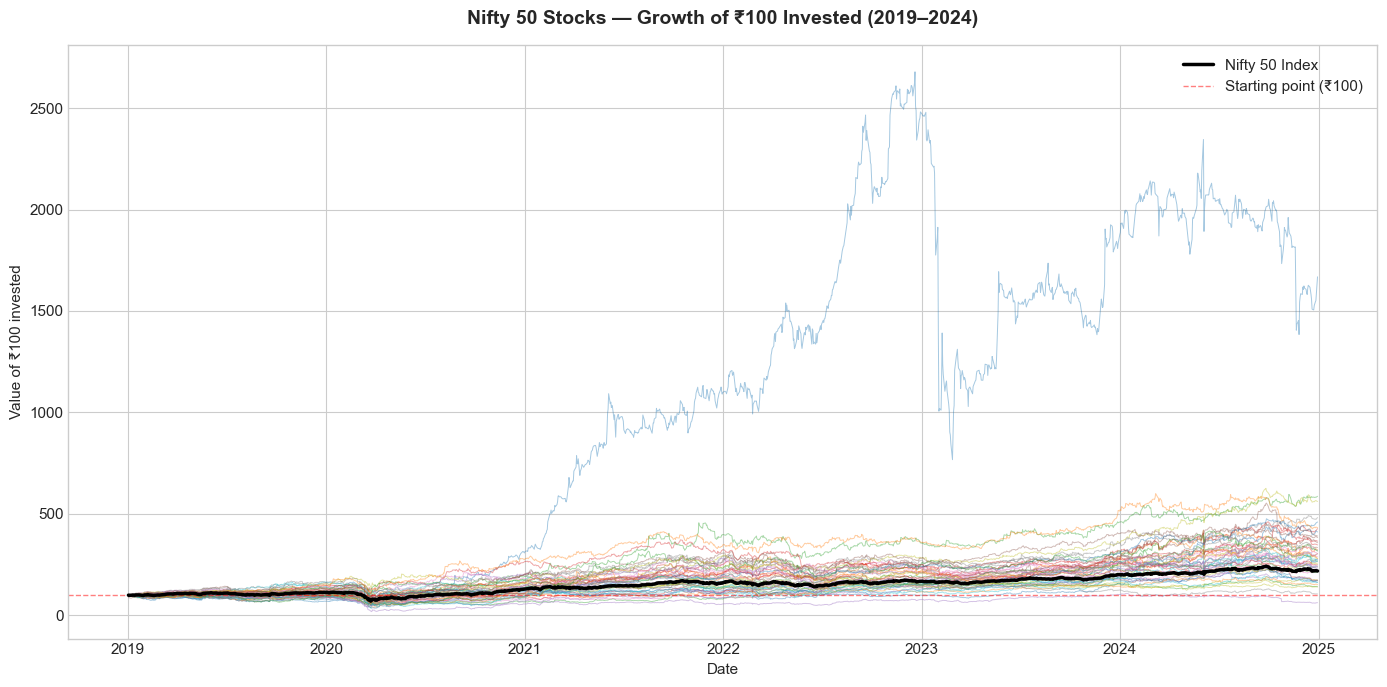

In [12]:
# CHART 1: ALL STOCKS GROWTH 

fig, ax = plt.subplots(figsize=(14, 7))

for column in normalised.columns:
    ax.plot(
        normalised.index,          
        normalised[column],      
        linewidth=0.7,          
        alpha=0.4                
    )

# Adding the Nifty 50 index as a thick black line for comparison
index_normalised = (index_price / index_price.iloc[0]) * 100
ax.plot(
    index_normalised.index,
    index_normalised,
    color='black',
    linewidth=2.5,
    label='Nifty 50 Index',
    zorder=5                        # zorder puts this line on top of all others
)

# Labels and title
ax.set_title('Nifty 50 Stocks — Growth of ₹100 Invested (2019–2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Value of ₹100 invested')
ax.axhline(y=100, color='red', linestyle='--',
           linewidth=1, alpha=0.5, label='Starting point (₹100)')
# axhline draws a horizontal line — here at y=100 (the starting value)

ax.legend(fontsize=11)
plt.tight_layout()   # adjusting spacing so nothing gets cut off
plt.show()

In [13]:
final_values = normalised.iloc[-1].sort_values(ascending=False)

print("Top 10 best performing stocks (2019-2024):")
print(final_values.head(10).round(1))

print("\nBottom 10 worst performing stocks:")
print(final_values.tail(10).round(1))

Top 10 best performing stocks (2019-2024):
Ticker
ADANIENT.NS      1668.4
APOLLOHOSP.NS     587.1
BHARTIARTL.NS     561.2
HCLTECH.NS        482.2
SUNPHARMA.NS      460.4
TATACONSUM.NS     433.2
DIVISLAB.NS       428.1
M&M.NS            411.2
POWERGRID.NS      391.5
BAJAJ-AUTO.NS     383.6
Name: 2024-12-30 00:00:00, dtype: float64

Bottom 10 worst performing stocks:
Ticker
HDFCBANK.NS      173.9
BRITANNIA.NS     171.9
AXISBANK.NS      171.3
HEROMOTOCO.NS    163.8
HDFCLIFE.NS      162.5
MARUTI.NS        152.5
HINDUNILVR.NS    143.1
KOTAKBANK.NS     139.7
UPL.NS           106.0
INDUSINDBK.NS     62.9
Name: 2024-12-30 00:00:00, dtype: float64


In [14]:
# SECTOR PERFORMANCE 

perf_df = final_values.reset_index()
perf_df.columns = ['ticker', 'total_return']

perf_df['sector'] = perf_df['ticker'].map(SECTORS)

sector_perf = perf_df.groupby('sector')['total_return'].mean().sort_values(ascending=False).round(1)

print("Average return by sector (₹100 invested in 2019):")
print(sector_perf)

Average return by sector (₹100 invested in 2019):
sector
Conglomerate    1668.4
Healthcare       587.1
Pharma           366.7
Consumer         358.4
Infra            334.4
IT               324.8
Materials        281.2
Auto             266.2
Energy           245.3
FMCG             235.1
Finance          234.8
Banking          198.9
Chemicals        106.0
Name: total_return, dtype: float64


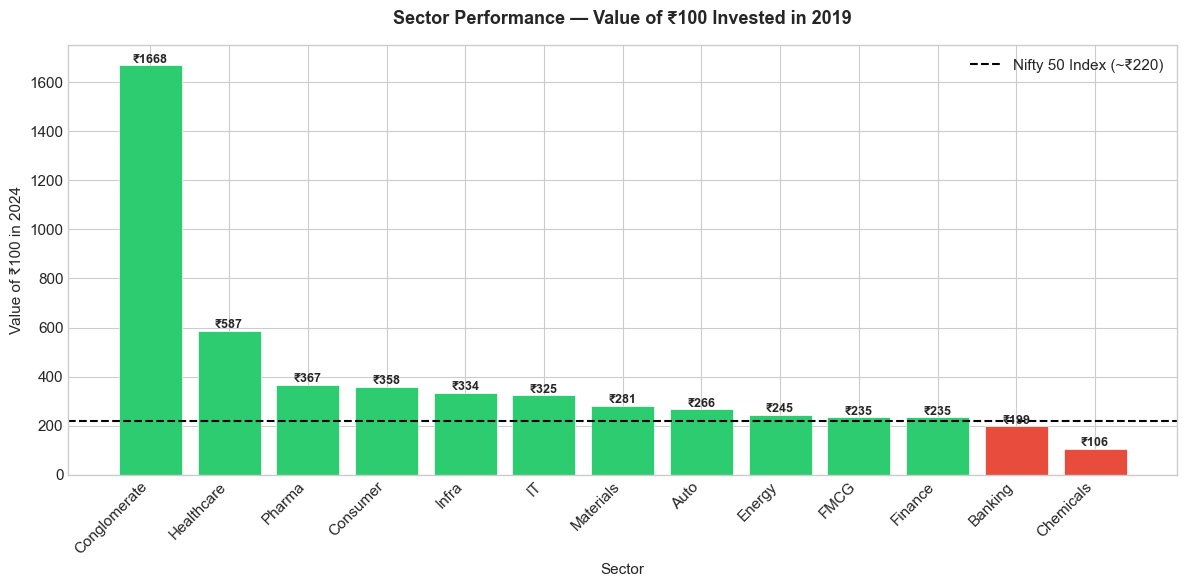

In [15]:
# CHART 2: SECTOR PERFORMANCE BAR CHART 

fig, ax = plt.subplots(figsize=(12, 6))

# Choose colours — green for above index, red for below
# Nifty 50 index ended at roughly 220
# So anything above 220 beat the market

colors = ['#2ecc71' if val > 220 else '#e74c3c' 
          for val in sector_perf.values]
# This is a "list comprehension" — a compact loop
# For each value: if above 220 use green, else use red

bars = ax.bar(
    sector_perf.index,    # x axis — sector names
    sector_perf.values,   # y axis — average return
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add value labels on top of each bar
for bar, val in zip(bars, sector_perf.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x position — centre of bar
        bar.get_height() + 10,               # y position — just above bar
        f'₹{val:.0f}',                       # the label text
        ha='center',                         # ha = horizontal alignment
        fontsize=9,
        fontweight='bold'
    )

# Reference line — where the Nifty 50 index ended
ax.axhline(y=220, color='black', linestyle='--',
           linewidth=1.5, label='Nifty 50 Index (~₹220)')

ax.set_title('Sector Performance — Value of ₹100 Invested in 2019',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Sector')
ax.set_ylabel('Value of ₹100 in 2024')
ax.legend()
plt.xticks(rotation=45, ha='right')
# rotation=45 tilts the x labels so they don't overlap
plt.tight_layout()
plt.show()

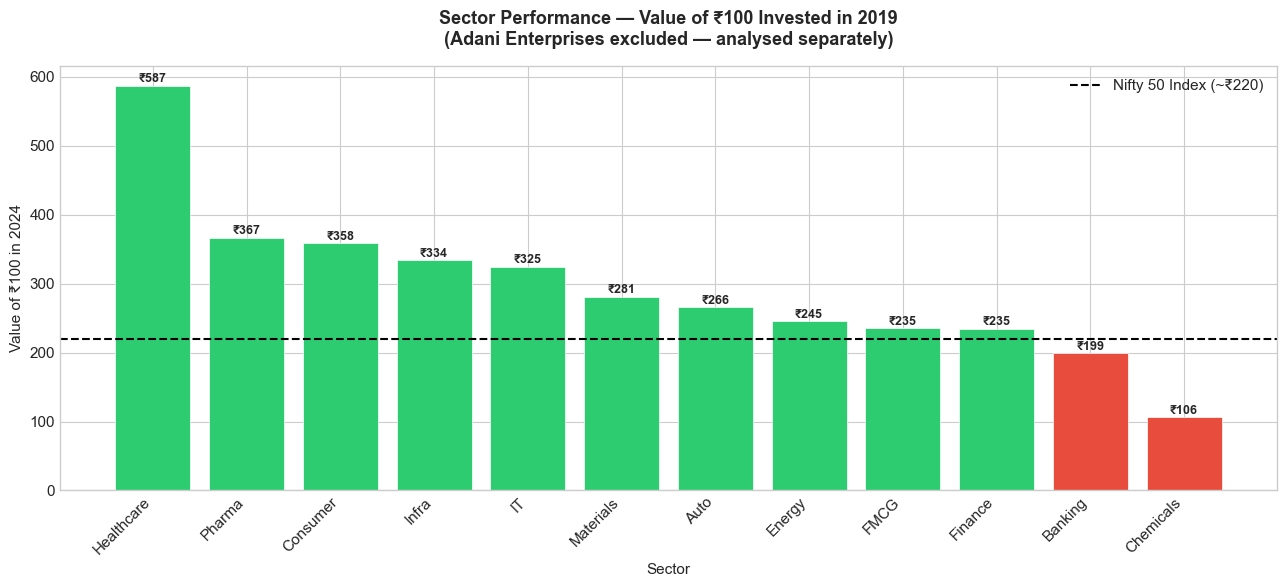

OUTLIER NOTE — Adani Enterprises (ADANIENT.NS)
₹100 invested in Jan 2019 to ₹1668 by Dec 2024
Return: 1568%
This is 5.7x the average
of all other sectors combined.

Driver: Rapid infrastructure expansion,government contracts, aggressive capital deployment.
Treated as individual outlier — not representative of broader Conglomerate sector trends.


In [16]:
# CHART 2 (REVISED): SECTOR PERFORMANCE 

# Remove Conglomerate from the sector performance series
sector_perf_clean = sector_perf.drop('Conglomerate')

# Colours — green if beat index (~220), red if below
colors = ['#2ecc71' if val > 220 else '#e74c3c'
          for val in sector_perf_clean.values]

fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(
    sector_perf_clean.index,
    sector_perf_clean.values,
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Value labels on top of each bar
for bar, val in zip(bars, sector_perf_clean.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'₹{val:.0f}',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

# Nifty 50 index reference line
ax.axhline(y=220, color='black', linestyle='--',
           linewidth=1.5, label='Nifty 50 Index (~₹220)')

ax.set_title('Sector Performance — Value of ₹100 Invested in 2019\n'
             '(Adani Enterprises excluded — analysed separately)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Sector')
ax.set_ylabel('Value of ₹100 in 2024')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ADANI SEPARATE CALLOUT 
print("=" * 45+ "\nOUTLIER NOTE — Adani Enterprises (ADANIENT.NS)\n"+ "=" * 45)
adani_return = normalised['ADANIENT.NS'].iloc[-1]
print(f"₹100 invested in Jan 2019 to ₹{adani_return:.0f} by Dec 2024")
print(f"Return: {adani_return - 100:.0f}%")
print(f"This is {adani_return/sector_perf_clean.mean():.1f}x the average")
print("of all other sectors combined.")
print("\nDriver: Rapid infrastructure expansion,government contracts, aggressive capital deployment.")
print("Treated as individual outlier — not representative of broader Conglomerate sector trends.")

In [17]:
# CHART 3: CORRELATION HEATMAP 
correlation_matrix = daily_returns.corr()
print(f"Correlation matrix shape: {correlation_matrix.shape}")
print("\nSample — correlation of TCS with a few others:")
print(correlation_matrix['TCS.NS'][['INFY.NS','HDFCBANK.NS', 'SUNPHARMA.NS']].round(2))

Correlation matrix shape: (49, 49)

Sample — correlation of TCS with a few others:
Ticker
INFY.NS         0.64
HDFCBANK.NS     0.28
SUNPHARMA.NS    0.22
Name: TCS.NS, dtype: float64


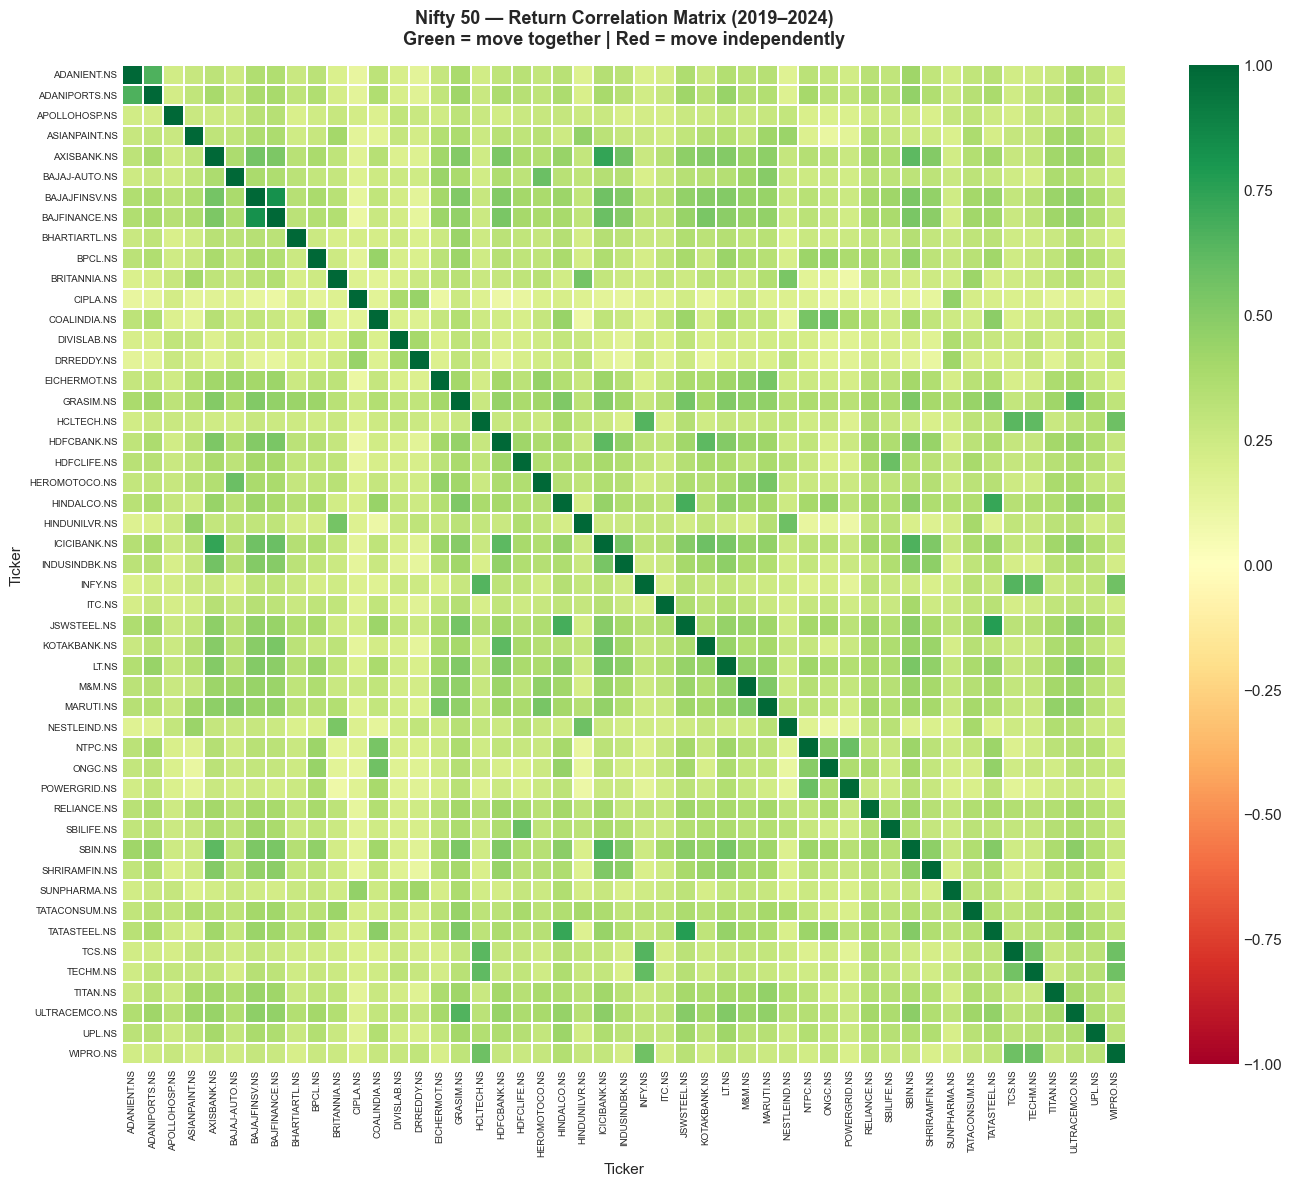

In [18]:
# CHART 3: CORRELATION HEATMAP 

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    linewidths=0.1,
    linecolor='white',
    ax=ax
)

ax.set_title('Nifty 50 — Return Correlation Matrix (2019–2024)\n'
             'Green = move together | Red = move independently',
             fontsize=13, fontweight='bold', pad=15)

# Rotate labels so they don't overlap
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)

plt.tight_layout()
plt.show()

In [19]:
# FINDING 3: Correlation Analysis
# Most Nifty 50 stocks show moderate positive correlation (0.3-0.6)
# suggesting broad market movements affect all stocks simultaneously.
# Strongest correlations appear within sectors — particularly
# Banking (HDFCBANK, AXISBANK, KOTAKBANK) and Finance (BAJFINANCE,
# BAJAJFINSV) — meaning intra-sector diversification is limited.
# True diversification requires cross-sector allocation.

In [20]:
# CHART 4: VOLATILITY ANALYSIS 

# Calculate annualised volatility for each stock
volatility = daily_returns.std() * (252 ** 0.5)
# 252 ** 0.5 means square root of 252

volatility = volatility.sort_values(ascending=False)

# Add sector labels
vol_df = volatility.reset_index()
vol_df.columns = ['ticker', 'volatility']
vol_df['sector'] = vol_df['ticker'].map(SECTORS)

print("Most volatile stocks:")
print(vol_df.head(5).round(3))
print("\nLeast volatile stocks:")
print(vol_df.tail(5).round(3))

Most volatile stocks:
          ticker  volatility        sector
0    ADANIENT.NS       0.534  Conglomerate
1  INDUSINDBK.NS       0.484       Banking
2  SHRIRAMFIN.NS       0.465       Finance
3  ADANIPORTS.NS       0.403         Infra
4    HINDALCO.NS       0.396     Materials

Least volatile stocks:
           ticker  volatility  sector
44     DRREDDY.NS       0.250  Pharma
45   BRITANNIA.NS       0.244    FMCG
46         TCS.NS       0.242      IT
47  HINDUNILVR.NS       0.232    FMCG
48   NESTLEIND.NS       0.224    FMCG


In [21]:
# ANALYTICAL NOTE: Adani Enterprises Exception
# Adani is simultaneously the most volatile (0.534) and best performing stock (1668% return).
# However this return is driven by company specific factors (infrastructure expansion, government contracts) — not
# a reward for volatility itself.
# The Hindenburg crisis of Jan 2023 demonstrated the downside of this volatility — stock crashed 50%+ in days.
# Adani is treated as an outlier throughout this analysis.
# The low volatility factor is evaluated across the remaining 48 stocks as a group — not based on individual exceptions.

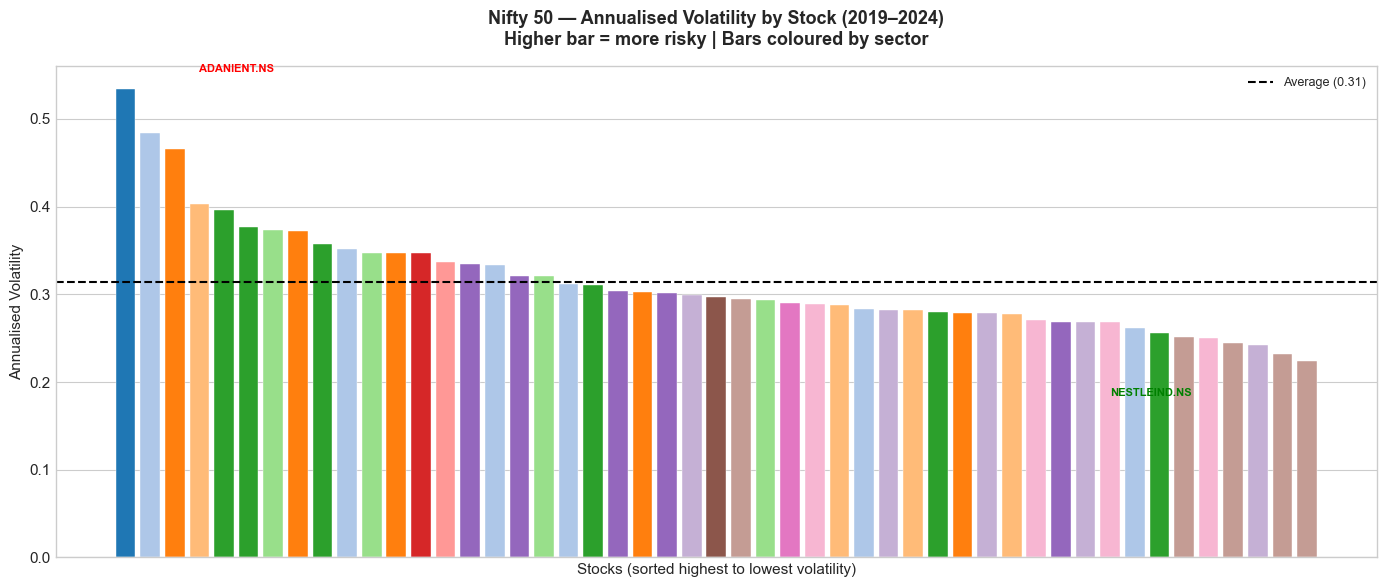


KEY FINDING:
Most volatile : ADANIENT.NS (53.4%) — Conglomerate
Least volatile: NESTLEIND.NS (22.4%) — FMCG
Average       : 31.4%
Spread        : 31.0%


In [22]:
# CHART 4: VOLATILITY ANALYSIS 

fig, ax = plt.subplots(figsize=(14, 6))

sectors_unique = vol_df['sector'].unique()
colors_map = dict(zip(sectors_unique,
                  plt.cm.tab20.colors[:len(sectors_unique)]))
# zip() pairs each sector with a colour
# dict() converts those pairs into a dictionary
# plt.cm.tab20 is a built in colour palette with 20 distinct colours

bar_colors = vol_df['sector'].map(colors_map)

bars = ax.bar(
    range(len(vol_df)),        # x axis — just numbers 0,1,2...49
    vol_df['volatility'],      # y axis — volatility value
    color=bar_colors,
    edgecolor='white',
    linewidth=0.3
)

# Add average line
avg_vol = vol_df['volatility'].mean()
ax.axhline(y=avg_vol, color='black', linestyle='--',
           linewidth=1.5, label=f'Average ({avg_vol:.2f})')

# Label the most and least volatile stocks
ax.annotate(vol_df['ticker'].iloc[0],           # most volatile
            xy=(0, vol_df['volatility'].iloc[0]),
            xytext=(3, vol_df['volatility'].iloc[0] + 0.02),
            fontsize=8, fontweight='bold', color='red')

ax.annotate(vol_df['ticker'].iloc[-1],          # least volatile
            xy=(48, vol_df['volatility'].iloc[-1]),
            xytext=(40, vol_df['volatility'].iloc[-1] - 0.04),
            fontsize=8, fontweight='bold', color='green')

ax.set_title('Nifty 50 — Annualised Volatility by Stock (2019–2024)\n'
             'Higher bar = more risky | Bars coloured by sector',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Stocks (sorted highest to lowest volatility)')
ax.set_ylabel('Annualised Volatility')
ax.set_xticks([])    # hide x tick numbers — too many to show
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Print the finding
print("\nKEY FINDING:")
print(f"Most volatile : {vol_df['ticker'].iloc[0]} "
      f"({vol_df['volatility'].iloc[0]:.1%}) — {vol_df['sector'].iloc[0]}")
print(f"Least volatile: {vol_df['ticker'].iloc[-1]} "
      f"({vol_df['volatility'].iloc[-1]:.1%}) — {vol_df['sector'].iloc[-1]}")
print(f"Average       : {avg_vol:.1%}")
print(f"Spread        : {vol_df['volatility'].iloc[0] - vol_df['volatility'].iloc[-1]:.1%}")

In [23]:
# FACTOR 1: MOMENTUM 
# Formula: price(today - 21 days) / price(today - 252 days) - 1
# Price from 1 month ago
price_1m_ago  = prices.shift(21)
# Price from 12 months ago
price_12m_ago = prices.shift(252)

momentum = (price_1m_ago / price_12m_ago) - 1

print("Momentum factor — first few values for TCS:")
print(momentum['TCS.NS'].dropna().head(5).round(4))

print(f"\nMomentum table shape: {momentum.shape}")
print(f"Non-null values     : {momentum.notna().sum().sum()}")
print("\nSample — momentum scores on last day:")
print(momentum.iloc[-1].dropna().sort_values(ascending=False).head(5).round(3))

Momentum factor — first few values for TCS:
Date
2020-01-14    0.1270
2020-01-15    0.1449
2020-01-16    0.1798
2020-01-17    0.1959
2020-01-20    0.2160
Name: TCS.NS, dtype: float64

Momentum table shape: (1480, 49)
Non-null values     : 60172

Sample — momentum scores on last day:
Ticker
M&M.NS           0.718
DIVISLAB.NS      0.608
BHARTIARTL.NS    0.587
SHRIRAMFIN.NS    0.502
POWERGRID.NS     0.486
Name: 2024-12-30 00:00:00, dtype: float64


In [24]:
# FACTOR 2: LOW VOLATILITY 
rolling_vol = daily_returns.rolling(126).std()
low_vol_factor = rolling_vol * -1

print("Low volatility factor — last day scores:")
print(low_vol_factor.iloc[-1].dropna()
      .sort_values(ascending=False).head(5).round(4))

print("\nMeaning: less negative = lower volatility = better score")

Low volatility factor — last day scores:
Ticker
SUNPHARMA.NS   -0.0105
NESTLEIND.NS   -0.0105
ICICIBANK.NS   -0.0116
ITC.NS         -0.0116
KOTAKBANK.NS   -0.0119
Name: 2024-12-30 00:00:00, dtype: float64

Meaning: less negative = lower volatility = better score


In [25]:
# FACTOR 3: MEAN REVERSION  
short_return = prices.pct_change(21) 
mean_reversion_factor = short_return * -1 
print("Mean reversion factor — last day scores:") 
print(mean_reversion_factor.iloc[-1].dropna() .sort_values(ascending=False).head(5).round(4)) 
print("\nMeaning: positive score = stock fell last month") 
print(" = candidate for bounce back")

Mean reversion factor — last day scores:
Ticker
HEROMOTOCO.NS    0.1246
COALINDIA.NS     0.0898
NTPC.NS          0.0847
UPL.NS           0.0844
POWERGRID.NS     0.0782
Name: 2024-12-30 00:00:00, dtype: float64

Meaning: positive score = stock fell last month
 = candidate for bounce back


In [26]:
# COMBINE FACTORS INTO ONE SCORE 

def standardise(factor):
    """
    Converts raw factor scores to Z-scores.
    Each stock is scored relative to all other stocks
    on the same day.
    """
    mean = factor.mean(axis=1)  # average score across all stocks that day
    std  = factor.std(axis=1)   # spread of scores across all stocks that day
    z = factor.sub(mean, axis=0).div(std, axis=0)
    return z

# Standardise all three factors
momentum_z   = standardise(momentum)
low_vol_z    = standardise(low_vol_factor)
mean_rev_z   = standardise(mean_reversion_factor)

combined_score = (momentum_z + low_vol_z + mean_rev_z) / 3

print("Combined factor scores — last day:")
print(combined_score.iloc[-1].dropna().sort_values(ascending=False).round(3))

Combined factor scores — last day:
Ticker
POWERGRID.NS     0.987
HEROMOTOCO.NS    0.981
BHARTIARTL.NS    0.625
SBIN.NS          0.552
NTPC.NS          0.501
ICICIBANK.NS     0.444
COALINDIA.NS     0.437
GRASIM.NS        0.424
DIVISLAB.NS      0.375
RELIANCE.NS      0.281
HINDUNILVR.NS    0.278
SUNPHARMA.NS     0.258
ONGC.NS          0.229
AXISBANK.NS      0.227
NESTLEIND.NS     0.223
JSWSTEEL.NS      0.198
HDFCBANK.NS      0.193
TCS.NS           0.191
ITC.NS           0.160
TECHM.NS         0.158
M&M.NS           0.154
SHRIRAMFIN.NS    0.138
TATASTEEL.NS     0.101
HDFCLIFE.NS      0.085
BAJAJ-AUTO.NS    0.079
HINDALCO.NS      0.049
KOTAKBANK.NS     0.045
HCLTECH.NS       0.037
BRITANNIA.NS     0.037
MARUTI.NS        0.026
UPL.NS           0.015
INFY.NS         -0.007
EICHERMOT.NS    -0.007
LT.NS           -0.040
TATACONSUM.NS   -0.086
ASIANPAINT.NS   -0.091
ULTRACEMCO.NS   -0.111
CIPLA.NS        -0.120
BPCL.NS         -0.126
APOLLOHOSP.NS   -0.172
SBILIFE.NS      -0.246
BAJAJFINSV.NS  

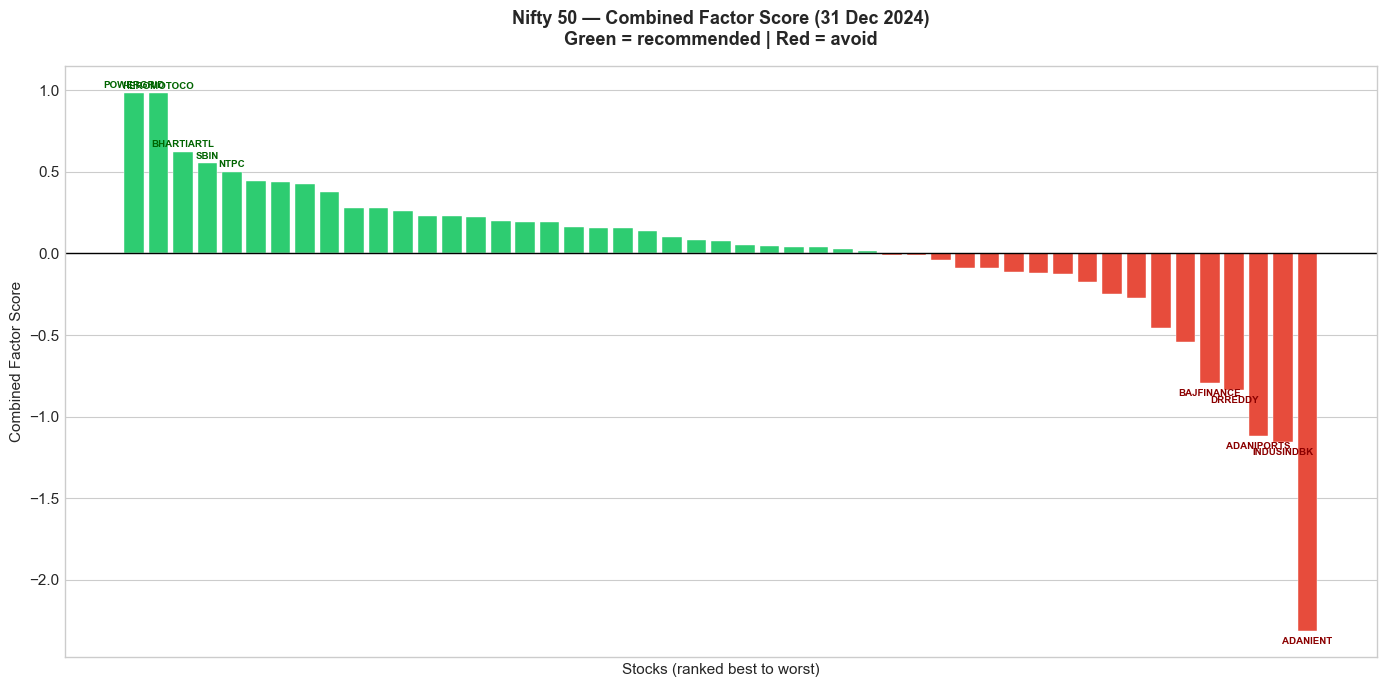


TOP 5 RECOMMENDATIONS (31 Dec 2024):
       ticker    score  sector
 POWERGRID.NS 0.986505   Infra
HEROMOTOCO.NS 0.981013    Auto
BHARTIARTL.NS 0.624629     NaN
      SBIN.NS 0.551856 Banking
      NTPC.NS 0.501033   Infra

BOTTOM 5 — AVOID:
       ticker     score       sector
BAJFINANCE.NS -0.791929      Finance
   DRREDDY.NS -0.834718       Pharma
ADANIPORTS.NS -1.120381        Infra
INDUSINDBK.NS -1.155086      Banking
  ADANIENT.NS -2.311328 Conglomerate


In [27]:
# CHART 5: FINAL FACTOR RANKINGS 

last_day = combined_score.iloc[-1].dropna().sort_values(ascending=False)

# Add sector colours
rank_df = last_day.reset_index()
rank_df.columns = ['ticker', 'score']
rank_df['sector'] = rank_df['ticker'].map(SECTORS)

# Colour by positive/negative score
colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in rank_df['score']]

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(
    range(len(rank_df)),
    rank_df['score'],
    color=colors,
    edgecolor='white',
    linewidth=0.3
)

# Label top 5 and bottom 5
for i in range(5):
    ax.text(i, rank_df['score'].iloc[i] + 0.03,
            rank_df['ticker'].iloc[i].replace('.NS',''),
            ha='center', fontsize=7, fontweight='bold', color='darkgreen')

for i in range(len(rank_df)-5, len(rank_df)):
    ax.text(i, rank_df['score'].iloc[i] - 0.08,
            rank_df['ticker'].iloc[i].replace('.NS',''),
            ha='center', fontsize=7, fontweight='bold', color='darkred')

ax.axhline(y=0, color='black', linewidth=1)
ax.set_title('Nifty 50 — Combined Factor Score (31 Dec 2024)\n'
             'Green = recommended | Red = avoid',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Stocks (ranked best to worst)')
ax.set_ylabel('Combined Factor Score')
ax.set_xticks([])
plt.tight_layout()
plt.show()

print(f"\nTOP 5 RECOMMENDATIONS (31 Dec 2024):")
print(rank_df.head(5)[['ticker','score','sector']].to_string(index=False))
print(f"\nBOTTOM 5 — AVOID:")
print(rank_df.tail(5)[['ticker','score','sector']].to_string(index=False))

In [28]:
# BACKTEST SETUP 

import pandas as pd

rebalance_dates = pd.date_range(
    start='2020-01-01',
    end='2024-12-31',
    freq='BME'
)

print(f"Total rebalancing periods: {len(rebalance_dates)}")
print(f"First rebalance date : {rebalance_dates[0].date()}")
print(f"Last rebalance date  : {rebalance_dates[-1].date()}")
print(f"\nFirst 6 dates:")
for d in rebalance_dates[:6]:
    print(f"  {d.date()}")

Total rebalancing periods: 60
First rebalance date : 2020-01-31
Last rebalance date  : 2024-12-31

First 6 dates:
  2020-01-31
  2020-02-28
  2020-03-31
  2020-04-30
  2020-05-29
  2020-06-30


In [29]:
#  MAIN BACKTEST LOOP 

strategy_returns = []   # stores our portfolio return each month
index_returns    = []   # stores Nifty 50 index return each month
dates_used       = []   # stores the date for each period
top10_history    = []   # stores which stocks we picked each month

for i in range(len(rebalance_dates) - 1):
    today      = rebalance_dates[i]      # decision date
    next_month = rebalance_dates[i + 1]  # when we measure return

   # Step 1: Get factor scores on decision date 
    try:
        scores = combined_score.asof(today).dropna()
    except:
        continue

    # Need at least 10 stocks with valid scores
    if len(scores) < 10:
        continue

    # Step 2: Pick top 10 stocks 
    top10 = scores.sort_values(ascending=False).head(10).index.tolist()

    # Step 3: Measure their return next month
    try:
        price_start = prices.asof(today)[top10]
        price_end   = prices.asof(next_month)[top10]
    except:
        continue

    # Monthly return for each stock
    stock_returns = (price_end / price_start) - 1

    # Portfolio return = equal weighted average of 10 stocks
    portfolio_return = stock_returns.mean()

    # Step 4: Nifty 50 index return same period 
    idx_start  = index_price.asof(today)
    idx_end    = index_price.asof(next_month)
    index_ret  = (idx_end / idx_start) - 1

    # Step 5: Record everything 
    strategy_returns.append(portfolio_return)
    index_returns.append(index_ret)
    dates_used.append(next_month)
    top10_history.append(top10)

# Convert to a DataFrame — one row per month
backtest = pd.DataFrame({
    'date'     : dates_used,
    'strategy' : strategy_returns,
    'index'    : index_returns,
})
backtest = backtest.set_index('date')

print(f"Backtest periods completed: {len(backtest)}")
print(f"\nFirst 6 months:")
print(backtest.head(6).round(4))
print(f"\nAverage monthly return:")
print(f"  Strategy : {backtest['strategy'].mean():.2%}")
print(f"  Index    : {backtest['index'].mean():.2%}")

Backtest periods completed: 59

First 6 months:
            strategy   index
date                        
2020-02-28   -0.0638 -0.0636
2020-03-31   -0.1777 -0.2325
2020-04-30    0.1413  0.1468
2020-05-29   -0.0218 -0.0284
2020-06-30    0.0207  0.0753
2020-07-31    0.0782  0.0749

Average monthly return:
  Strategy : 2.06%
  Index    : 1.31%


In [30]:
# BACKTEST SUMMARY STATISTICS 

strategy_cumulative = (1 + backtest['strategy']).cumprod() - 1
index_cumulative = (1 + backtest['index']).cumprod() - 1

final_strategy = strategy_cumulative.iloc[-1]
final_index = index_cumulative.iloc[-1]

# Annualised return
n_years = len(backtest) / 12
ann_strategy = (1 + final_strategy) ** (1/n_years) - 1
ann_index = (1 + final_index) ** (1/n_years) - 1

sharpe_strategy = (backtest['strategy'].mean() / backtest['strategy'].std()) * (12 ** 0.5)
sharpe_index = (backtest['index'].mean() / backtest['index'].std()) * (12 ** 0.5)

def max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    return drawdown.min()

mdd_strategy = max_drawdown(backtest['strategy'])
mdd_index = max_drawdown(backtest['index'])

wins = (backtest['strategy'] > backtest['index']).sum()
win_rate = wins / len(backtest)

print("=" * 50)
print(" BACKTEST RESULTS (Jan 2020 - Dec 2024)")
print("=" * 50)
print(f"{'Metric':<25} {'Strategy':>10} {'Index':>10}")
print("-" * 50)
print(f"{'Total Return':<25} {final_strategy:>10.1%} {final_index:>10.1%}")
print(f"{'Annualised Return':<25} {ann_strategy:>10.1%} {ann_index:>10.1%}")
print(f"{'Sharpe Ratio':<25} {sharpe_strategy:>10.2f} {sharpe_index:>10.2f}")
print(f"{'Max Drawdown':<25} {mdd_strategy:>10.1%} {mdd_index:>10.1%}")
print(f"{'Monthly Win Rate':<25} {win_rate:>10.1%} {'N/A':>10}")
print("=" * 50)

 BACKTEST RESULTS (Jan 2020 - Dec 2024)
Metric                      Strategy      Index
--------------------------------------------------
Total Return                  207.6%      97.7%
Annualised Return              25.7%      14.9%
Sharpe Ratio                    1.35       0.83
Max Drawdown                  -17.8%     -23.2%
Monthly Win Rate               69.5%        N/A


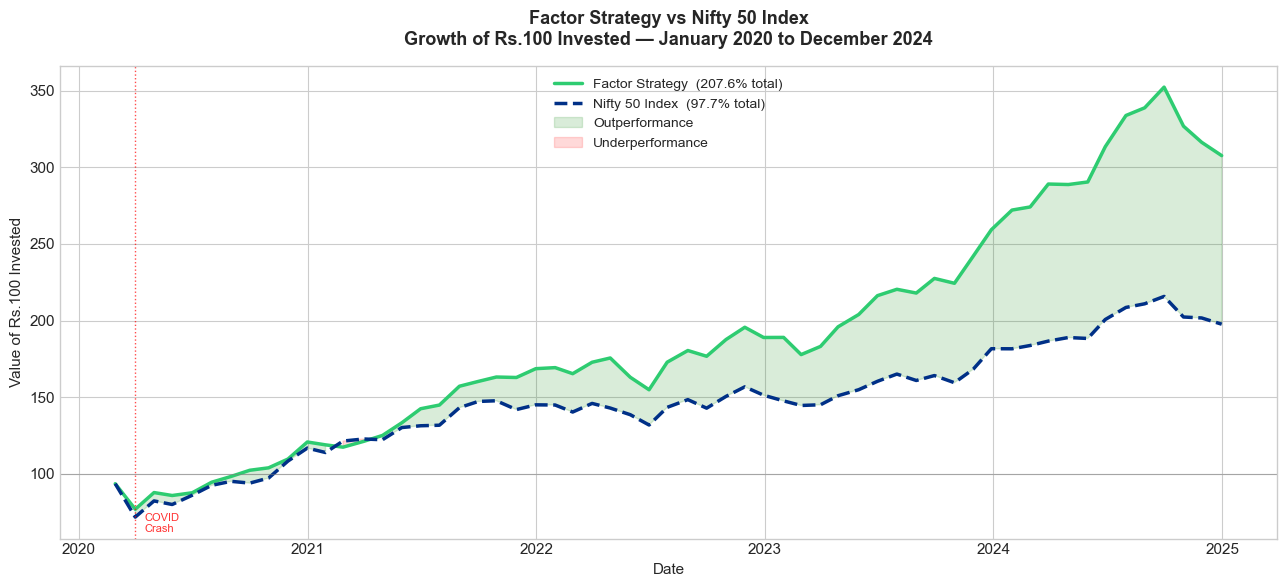


Rs.100 invested in Jan 2020 became:
  Factor strategy : Rs.308
  Nifty 50 index  : Rs.198
  Difference      : Rs.110 more


In [31]:
# CHART 6: CUMULATIVE RETURNS 

fig, ax = plt.subplots(figsize=(13, 6))

# Convert cumulative returns to ₹ value starting at 100
strategy_value = (1 + backtest['strategy']).cumprod() * 100
index_value    = (1 + backtest['index']).cumprod() * 100

# Plot both lines
ax.plot(strategy_value.index, strategy_value,
        color='#2ecc71', linewidth=2.5,
        label=f'Factor Strategy  ({final_strategy:.1%} total)')

ax.plot(index_value.index, index_value,
        color='#003087', linewidth=2.5,
        linestyle='--',
        label=f'Nifty 50 Index  ({final_index:.1%} total)')

# Shade the area between the two lines
ax.fill_between(strategy_value.index,
                strategy_value, index_value,
                where=strategy_value > index_value,
                alpha=0.15, color='green',
                label='Outperformance')

ax.fill_between(strategy_value.index,
                strategy_value, index_value,
                where=strategy_value < index_value,
                alpha=0.15, color='red',
                label='Underperformance')

# Mark the COVID crash
ax.axvline(x=pd.Timestamp('2020-03-31'),
           color='red', linestyle=':', linewidth=1,
           alpha=0.7)
ax.text(pd.Timestamp('2020-04-15'), 62,
        'COVID\nCrash', fontsize=8,
        color='red', alpha=0.8)

# Starting line
ax.axhline(y=100, color='grey', linestyle='-',
           linewidth=0.8, alpha=0.5)

ax.set_title('Factor Strategy vs Nifty 50 Index\n'
             'Growth of Rs.100 Invested — January 2020 to December 2024',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Value of Rs.100 Invested')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nRs.100 invested in Jan 2020 became:")
print(f"  Factor strategy : Rs.{strategy_value.iloc[-1]:.0f}")
print(f"  Nifty 50 index  : Rs.{index_value.iloc[-1]:.0f}")
print(f"  Difference      : Rs.{strategy_value.iloc[-1] - index_value.iloc[-1]:.0f} more")

In [32]:
# OUT OF SAMPLE VALIDATION — 2025 

print("Downloading 2025 out-of-sample data...")

# Download 2025 prices for same 49 stocks
oos_raw = yf.download(
    list(prices.columns),     
    start="2025-01-01",
    end="2025-05-31",        
    auto_adjust=True,
    progress=False
)

oos_prices = oos_raw['Close']
oos_prices = oos_prices.ffill().dropna(how='all')

# Download 2025 index
oos_index_raw = yf.download("^NSEI", start="2025-01-01",
                             end="2025-05-31", auto_adjust=True,
                             progress=False)
oos_index = oos_index_raw['Close'].squeeze()

print(f" 2025 data loaded: {oos_prices.shape}")
print(f" Date range: {oos_prices.index[0].date()} to {oos_prices.index[-1].date()}")

 2025 data loaded: (102, 49)
 Date range: 2025-01-01 - 2025-05-30


In [33]:
# OOS VALIDATION: APPLY FACTOR MODEL TO 2025 

final_rankings = combined_score.iloc[-1].dropna()\
                 .sort_values(ascending=False)

# Top 10 and bottom 10 stocks by factor score
top10    = final_rankings.head(10).index.tolist()
bottom10 = final_rankings.tail(10).index.tolist()

# Filter to stocks available in 2025 data
top10    = [s for s in top10    if s in oos_prices.columns]
bottom10 = [s for s in bottom10 if s in oos_prices.columns]

# Calculate 2025 returns for each group
oos_start = oos_prices.iloc[0]
oos_end   = oos_prices.iloc[-1]
oos_returns = (oos_end / oos_start) - 1

# Group returns
top10_return    = oos_returns[top10].mean()
bottom10_return = oos_returns[bottom10].mean()

# Index return over same period
idx_start  = oos_index.iloc[0]
idx_end    = oos_index.iloc[-1]
index_return = (idx_end / idx_start) - 1

print("=" * 50)
print("  OUT OF SAMPLE VALIDATION — 2025")
print("  (Data never seen during model construction)")
print("=" * 50)
print(f"\nPeriod: {oos_prices.index[0].date()} to {oos_prices.index[-1].date()}")
print(f"Trading days: {len(oos_prices)}")
print(f"\n{'Group':<20} {'Return':>10}")
print("-" * 35)
print(f"{'Top 10 (our picks)':<20} {top10_return:>10.1%}")
print(f"{'Bottom 10 (avoid)':<20} {bottom10_return:>10.1%}")
print(f"{'Nifty 50 Index':<20} {index_return:>10.1%}")
print("=" * 50)

# Did top 10 beat the index?
if top10_return > index_return:
    alpha = top10_return - index_return
    print(f"\n Top 10 OUTPERFORMED index by {alpha:.1%}")
    print("  Out of sample validation: PASSED")
else:
    underperformance = index_return - top10_return
    print(f"\n Top 10 underperformed index by {underperformance:.1%}")
    print("  Out of sample validation: needs investigation")

print(f"\nTop 10 stocks tested:")
for i, s in enumerate(top10, 1):
    print(f"  {i:2}. {s:20} {oos_returns[s]:.1%}")

  OUT OF SAMPLE VALIDATION — 2025
  (Data never seen during model construction)

Period: 2025-01-01 to 2025-05-30
Trading days: 102

Group                    Return
-----------------------------------
Top 10 (our picks)         6.8%
Bottom 10 (avoid)          7.0%
Nifty 50 Index             4.2%

 Top 10 OUTPERFORMED index by 2.6%
  Out of sample validation: PASSED

Top 10 stocks tested:
   1. POWERGRID.NS         -5.6%
   2. HEROMOTOCO.NS        5.6%
   3. BHARTIARTL.NS        16.3%
   4. SBIN.NS              4.5%
   5. NTPC.NS              0.9%
   6. ICICIBANK.NS         12.6%
   7. COALINDIA.NS         4.3%
   8. GRASIM.NS            4.2%
   9. DIVISLAB.NS          8.9%
  10. RELIANCE.NS          16.3%
